# Clustering Results Analysis

This notebook provides a comprehensive evaluation of clustering quality through:
- **Clustering Metrics**: Analysis of silhouette score, Calinski-Harabasz score, and Davies-Bouldin score across different cluster counts
- **Dimensionality Reduction Visualizations**: Interactive UMAP and t-SNE plots for visual cluster assessment
- **Cluster Distribution Analysis**: Examination of cluster size distributions and variability

## Overview

The analysis evaluates clustering performance across multiple cluster counts (k values) to identify optimal clustering configurations. Metrics are computed for each configuration, and visualizations help understand the structure and quality of the resulting clusters.

## 1. Configuration and Setup

First, we configure the environment paths and import necessary libraries.

In [1]:
import os
import warnings

import pandas as pd
import matplotlib.pyplot as plt

# Import clustering analysis utilities
from conclusions_utils import (
    get_cluster_counts,
    load_all_metrics,
    plot_all_metrics_evolution,
    clustering_distribution_histogram,
    get_all_predicted_labels_files,
    display_all_plots_interactive,
    extract_cluster_count,
)

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')



ModuleNotFoundError: No module named 'pandas'

Configure experiment path


In [ ]:
# Set environment variable
os.environ["OUTPUTS"] = "D:/new_projects/ssondo/training_ssondo/outputs"

# Update EXPERIMENT_NAME to match your clustering experiment
EXPERIMENT_NAME = "MATPAC_MCL"
exp_path = os.path.join(
    os.environ["OUTPUTS"],
    "clustering",
    EXPERIMENT_NAME
)

print(f"Experiment path: {exp_path}")
print(f"Path exists: {os.path.exists(exp_path)}")


Experiment path: D:/new_projects/ssondo/training_ssondo/outputs\clustering\MATPAC_MCL
Path exists: True


## 2. Load Clustering Metrics

Load and examine clustering quality metrics for all cluster configurations. These metrics help evaluate the quality of different clustering solutions.

In [ ]:
# Get available cluster counts from experiment directory
cluster_counts = get_cluster_counts(exp_path)

# Load all metrics for each cluster configuration
metrics_data = load_all_metrics(exp_path)
print(f"Summary: Loaded metrics for {len(metrics_data)} cluster configurations")


Available cluster counts: [10, 25, 50, 100, 200]
Loading all metrics...
Loaded metrics for 100 clusters
Loaded metrics for 10 clusters
Loaded metrics for 200 clusters
Loaded metrics for 25 clusters
Loaded metrics for 50 clusters

Available metrics: ['silhouette_score', 'calinski_harabasz_score', 'davies_bouldin_score']
Summary: Loaded metrics for 5 cluster configurations


## 3. Metrics Evolution Analysis

Visualize how clustering quality metrics evolve as the number of clusters changes. This helps identify optimal cluster counts.

**Key Metrics:**
- **Silhouette Score**: Measures how similar an object is to its own cluster compared to other clusters (higher is better, range: -1 to 1)
- **Calinski-Harabasz Score**: Ratio of between-cluster dispersion to within-cluster dispersion (higher is better)
- **Davies-Bouldin Score**: Average similarity ratio of clusters (lower is better)

Plotting evolution for all metrics: ['silhouette_score', 'calinski_harabasz_score', 'davies_bouldin_score']

Plotting silhouette_score...


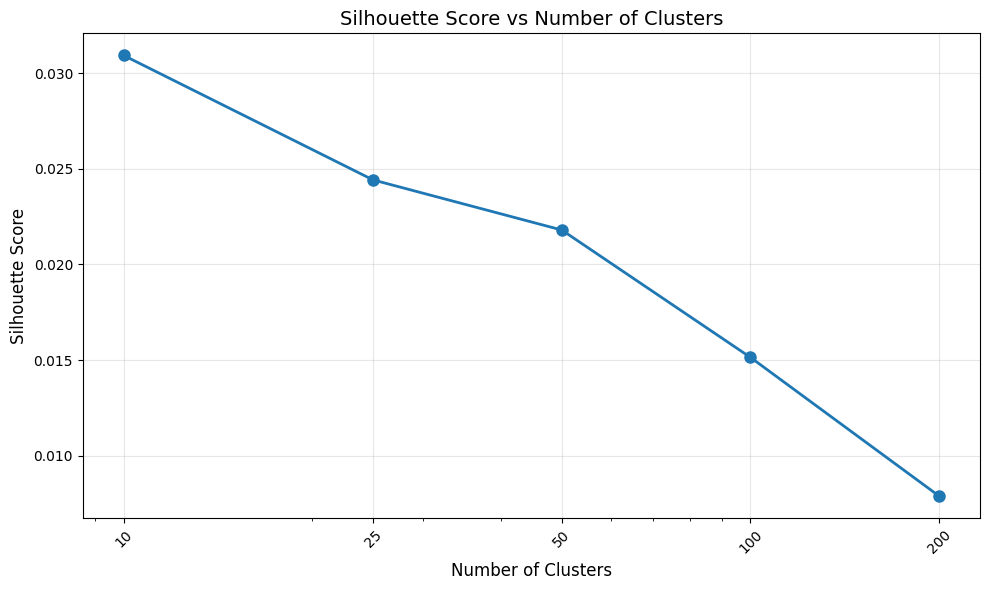


Plotting calinski_harabasz_score...


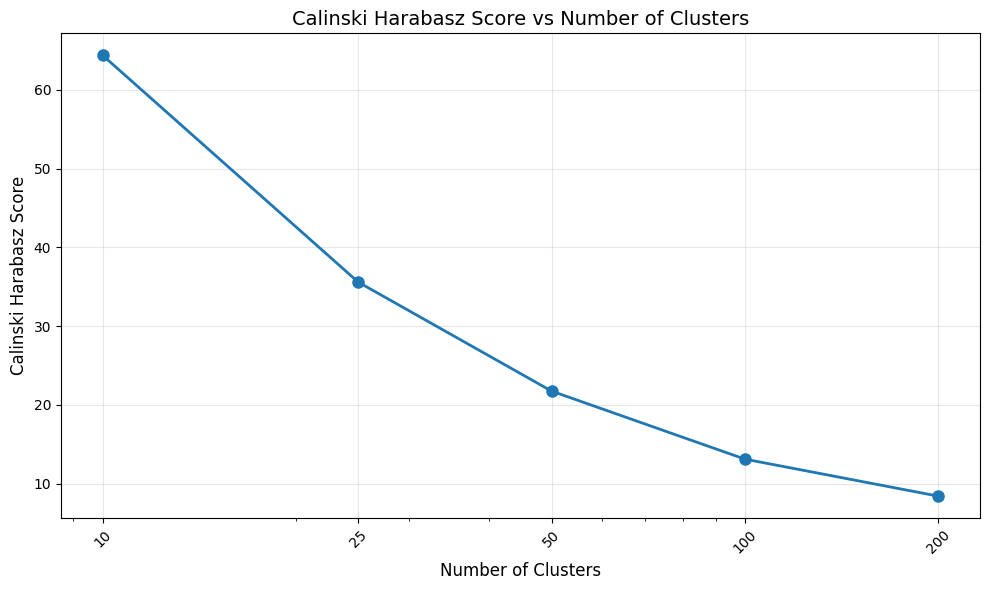


Plotting davies_bouldin_score...


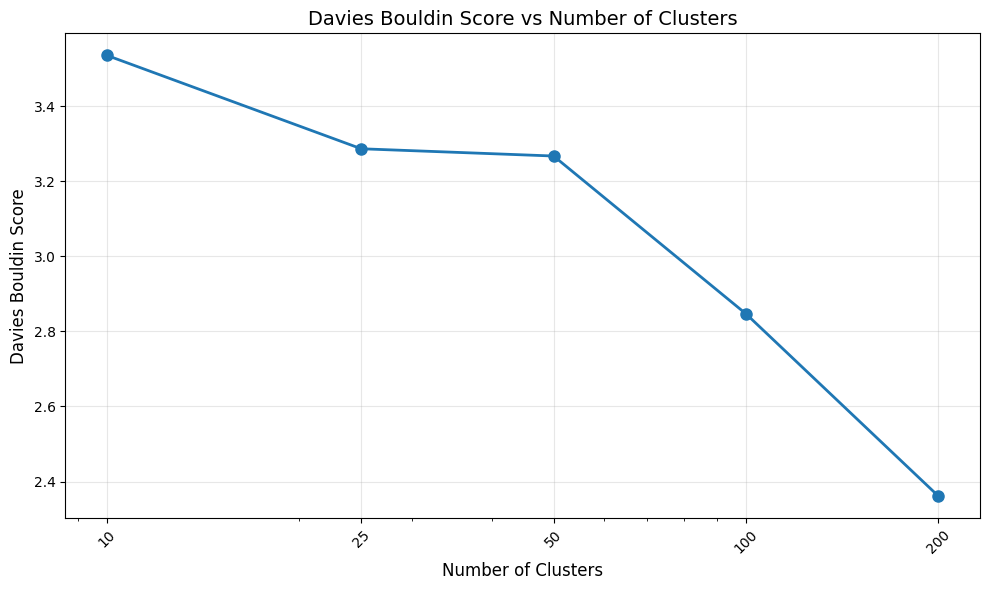

In [ ]:
# Plot all metrics evolution simultaneously
plot_all_metrics_evolution(metrics_data)



## 4. Dimensionality Reduction Visualizations

Visualize clusters in 2D space using dimensionality reduction techniques. These visualizations help understand cluster structure and separation.

**Visualization Methods:**
- **UMAP**: Uniform Manifold Approximation and Projection - preserves both local and global structure
- **t-SNE**: t-Distributed Stochastic Neighbor Embedding - emphasizes local structure and cluster separation

Interactive plots are saved as HTML files for detailed exploration.

In [ ]:
# Generate interactive UMAP visualization comparison
# The plot is saved as an HTML file that can be opened in a browser
display_all_plots_interactive(exp_path, "umap")


Found 5 UMAP CSV files to display
Saved interactive plot to: D:/new_projects/ssondo/training_ssondo/outputs\clustering\MATPAC_MCL\umap_comparison.html
Open this file in your browser to view the interactive plot.


In [ ]:
# Generate interactive t-SNE visualization comparison
# The plot is saved as an HTML file that can be opened in a browser
display_all_plots_interactive(exp_path, "tsne")


Found 5 TSNE CSV files to display
Saved interactive plot to: D:/new_projects/ssondo/training_ssondo/outputs\clustering\MATPAC_MCL\tsne_comparison.html
Open this file in your browser to view the interactive plot.


## 5. Cluster Distribution Analysis

Analyze how data samples are distributed across clusters. This helps identify:
- **Cluster Balance**: Whether clusters are evenly sized or imbalanced
- **Distribution Patterns**: How samples are allocated across different cluster configurations
- **Variability**: Consistency of cluster sizes across different k values


Generating histogram for 10 clusters...


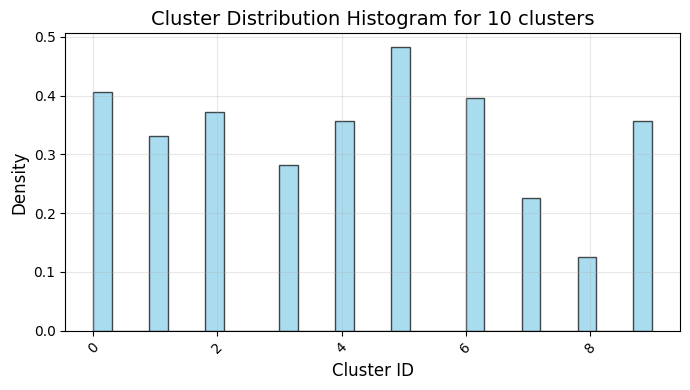


Generating histogram for 25 clusters...


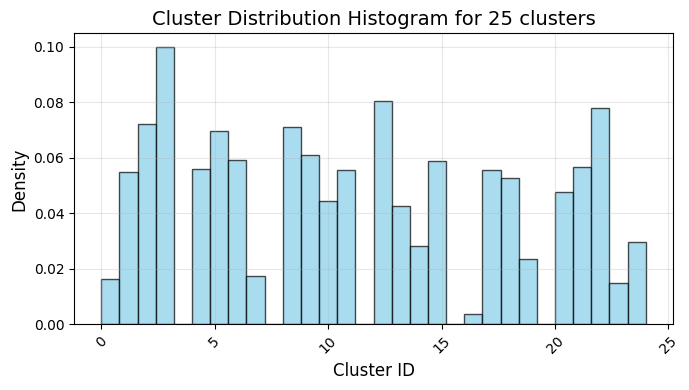


Generating histogram for 50 clusters...


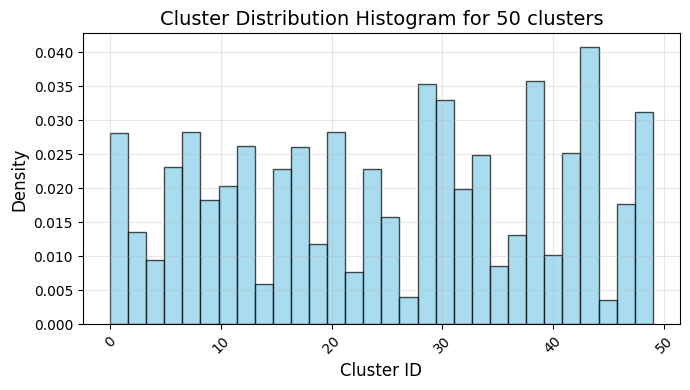


Generating histogram for 100 clusters...


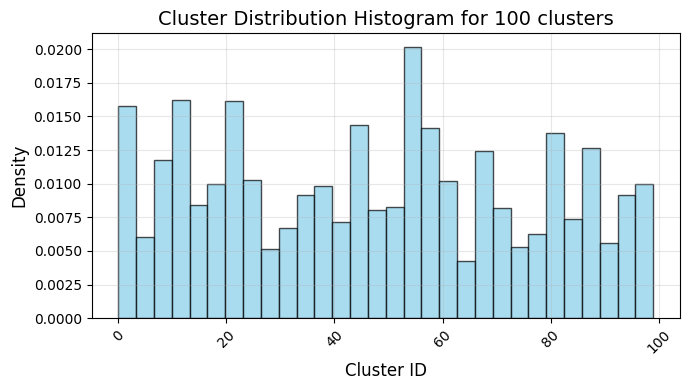


Generating histogram for 200 clusters...


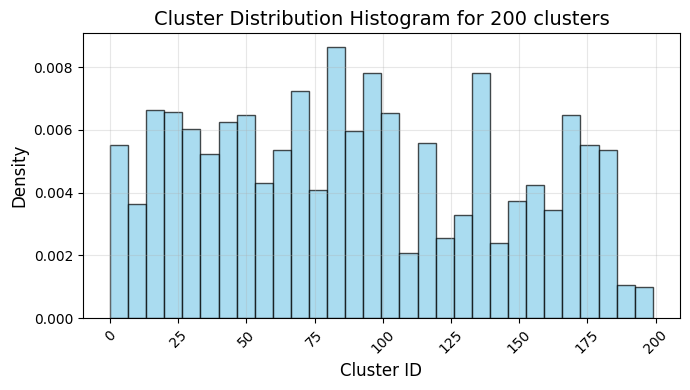

In [ ]:
# Find and sort all predicted labels files
predicted_labels_files = get_all_predicted_labels_files(exp_path)
predicted_labels_files = sorted(predicted_labels_files, key=extract_cluster_count)

# Generate cluster distribution histograms for each configuration
# These show how samples are distributed across clusters
HISTOGRAM_BINS = 30
HISTOGRAM_FIGSIZE = (7, 4)

for file in predicted_labels_files:
    k = extract_cluster_count(file)
    print(f"\nGenerating histogram for {k} clusters...")
    clustering_distribution_histogram(file, bins=HISTOGRAM_BINS, figsize=HISTOGRAM_FIGSIZE)